# Statistical visualization with Seaborn

> **Explain it like I am five:** Matplotlib gives you pencils and paper. Seaborn gives you helpful stencils that can automatically group, summarize, and color data while still drawing on Matplotlib paper.

Seaborn is built on Matplotlib and works naturally with tidy Pandas DataFrames. This rewrite preserves all original plot types and makes the `tips` lesson work offline with deterministic sample data.

## Learning goals

- understand tidy data and semantic mappings (`hue`, `style`, `size`);
- create relational, categorical, distribution, and matrix plots;
- understand Seaborn's automatic aggregation and uncertainty;
- customize and validate plots using Matplotlib.


## 0. Setup

Install once only if needed:

```python
%pip install seaborn matplotlib pandas
```

The original notebook used `!pip install seaborn`; setup should not rerun with every lesson execution.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
print("Seaborn version:", sns.__version__)


Seaborn version: 0.13.2


In [2]:
from pathlib import Path

def data_path(filename):
    """Find a course data file whether Jupyter starts in the repo or lesson folder."""
    current = Path.cwd().resolve()
    lesson_parts = ("Complete-Python-Bootcamp-main", "10-Data Analysis With Python")
    candidates = [current / filename, current.joinpath(*lesson_parts, filename)]
    for parent in current.parents:
        candidates.extend([parent / filename, parent.joinpath(*lesson_parts, filename)])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r}. Start Jupyter inside this repository.")


## 1. Tidy data and an offline `tips` table

Tidy data means:

- one row per observation;
- one column per variable;
- one cell per value.

The original `tips=sns.load_dataset('tips')` downloads a dataset. Set the flag to `True` when internet is available. The default creates the same kind of columns locally and reproducibly.


In [3]:
RUN_LIVE_DATASET_EXAMPLE = False

if RUN_LIVE_DATASET_EXAMPLE:
    tips=sns.load_dataset('tips')
else:
    rng = np.random.default_rng(7)
    row_count = 96
    party_size = rng.integers(1, 7, row_count)
    total_bill = np.clip(rng.normal(8 + party_size * 5, 6, row_count), 5, None).round(2)
    tip = np.clip(total_bill * rng.normal(0.16, 0.035, row_count), 1, None).round(2)
    tips = pd.DataFrame({
        'total_bill': total_bill,
        'tip': tip,
        'sex': rng.choice(['Female', 'Male'], row_count),
        'smoker': rng.choice(['Yes', 'No'], row_count, p=[0.3, 0.7]),
        'day': rng.choice(['Thur', 'Fri', 'Sat', 'Sun'], row_count, p=[0.2, 0.15, 0.35, 0.3]),
        'time': rng.choice(['Lunch', 'Dinner'], row_count, p=[0.35, 0.65]),
        'size': party_size
    })

tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,38.72,5.12,Male,Yes,Sun,Dinner,6
1,24.15,3.33,Female,Yes,Sun,Dinner,4
2,45.00,5.19,Male,No,Sun,Dinner,5
3,42.57,8.68,Male,No,Sun,Dinner,6
4,20.80,3.22,Male,No,Sun,Dinner,4


In [4]:
print("shape:", tips.shape)
print(tips.dtypes)
print(tips.describe(include='all'))


shape: (96, 7)
total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object
        total_bill        tip   sex smoker  day    time       size
count    96.000000  96.000000    96     96   96      96  96.000000
unique         NaN        NaN     2      2    4       2        NaN
top            NaN        NaN  Male     No  Sat  Dinner        NaN
freq           NaN        NaN    52     64   40      62        NaN
mean     25.849479   4.058958   NaN    NaN  NaN     NaN   3.645833
std      10.338992   1.885707   NaN    NaN  NaN     NaN   1.734960
min       5.000000   1.000000   NaN    NaN  NaN     NaN   1.000000
25%      18.225000   2.642500   NaN    NaN  NaN     NaN   2.000000
50%      25.875000   3.875000   NaN    NaN  NaN     NaN   4.000000
75%      33.172500   5.142500   NaN    NaN  NaN     NaN   5.000000
max      46.630000   9.900000   NaN    NaN  NaN     NaN   6.000000


## 2. Scatter plot and semantic mappings

A scatter plot shows one dot per row. `hue`, `style`, and `size` map extra columns to visible properties.


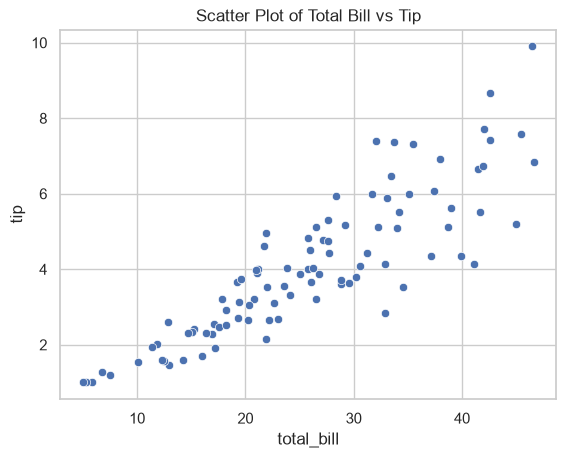

In [5]:
## create a scatter plot
sns.scatterplot(x='total_bill',y='tip',data=tips)
plt.title("Scatter Plot of Total Bill vs Tip")
plt.show()


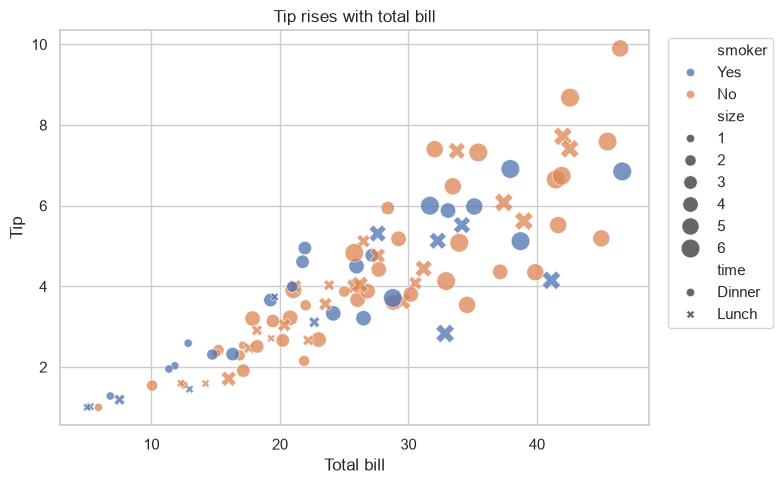

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    style='time',
    size='size',
    sizes=(35, 180),
    alpha=0.75,
    ax=ax
)
ax.set(title='Tip rises with total bill', xlabel='Total bill', ylabel='Tip')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()


Too many semantic mappings can overload a chart. Add only a variable that helps answer the question.


## 3. Line plot and automatic aggregation

The original example has repeated party sizes. Seaborn groups equal x-values and plots an estimate (mean by default), often with an uncertainty band. It is not connecting individual meals in time order.


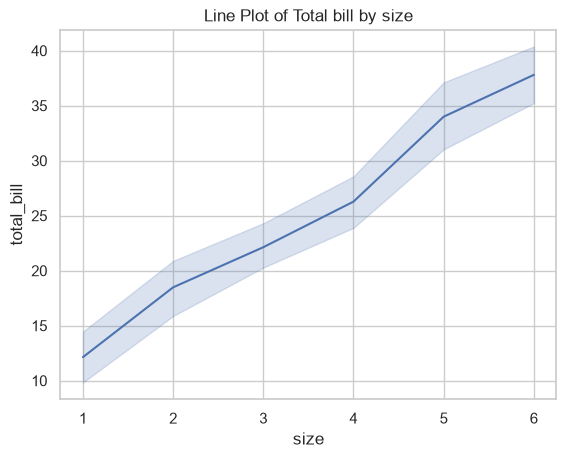

In [7]:
## Line Plot

sns.lineplot(x='size',y='total_bill',data=tips)
plt.title("Line Plot of Total bill by size")
plt.show()


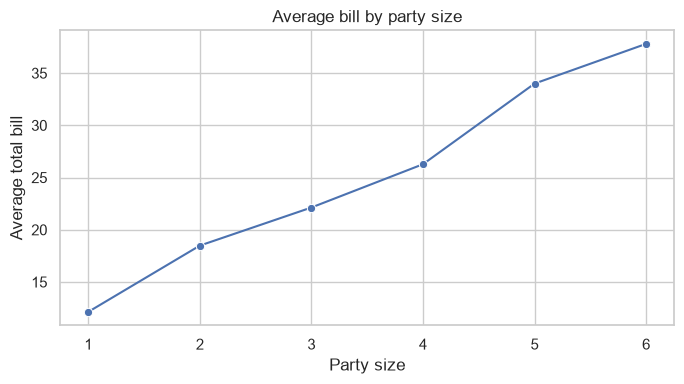

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(
    data=tips,
    x='size',
    y='total_bill',
    estimator='mean',
    errorbar=None,
    marker='o',
    ax=ax
)
ax.set(title='Average bill by party size', xlabel='Party size', ylabel='Average total bill')
fig.tight_layout()
plt.show()


## 4. Categorical bar plot

`sns.barplot` estimates a statistic per category. The default statistic is the mean; it is not automatically a total. State the estimator and uncertainty choice clearly.


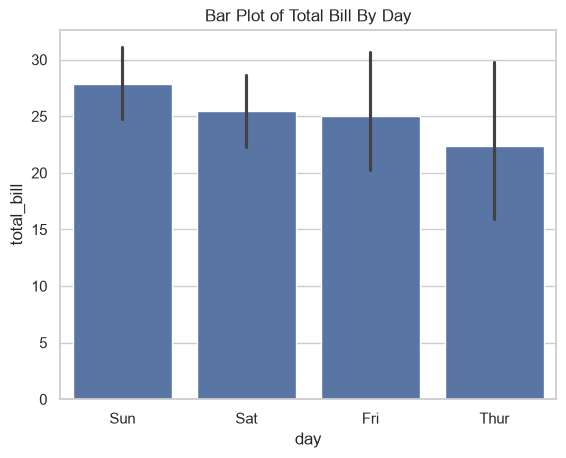

In [9]:
## Categorical Plots
## Bar Plot
sns.barplot(x='day',y='total_bill',data=tips)
plt.title('Bar Plot of Total Bill By Day')
plt.show()


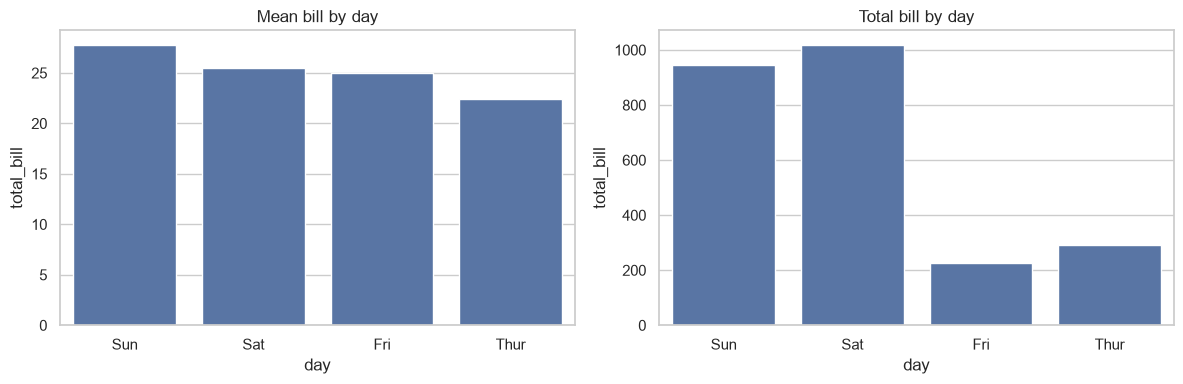

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=tips, x='day', y='total_bill', estimator='mean', errorbar=None, ax=axes[0])
axes[0].set_title('Mean bill by day')

sns.barplot(data=tips, x='day', y='total_bill', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title('Total bill by day')

fig.tight_layout()
plt.show()


## 5. Box and violin plots

A box plot summarizes median, quartiles, spread, and potential outliers. A violin adds a smoothed distribution shape; its width shows where values are dense.


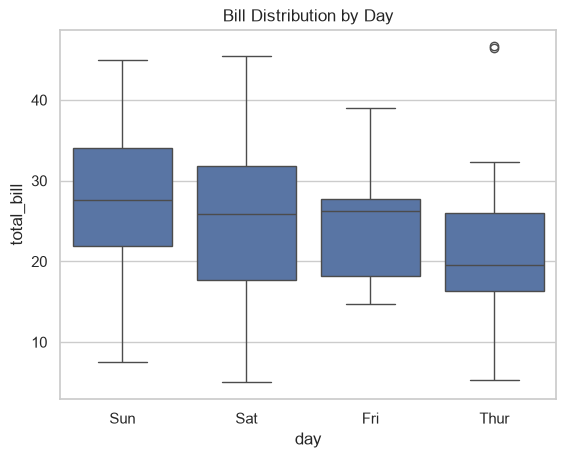

In [11]:
## Box Plot
sns.boxplot(x="day",y='total_bill',data=tips)
plt.title('Bill Distribution by Day')
plt.show()


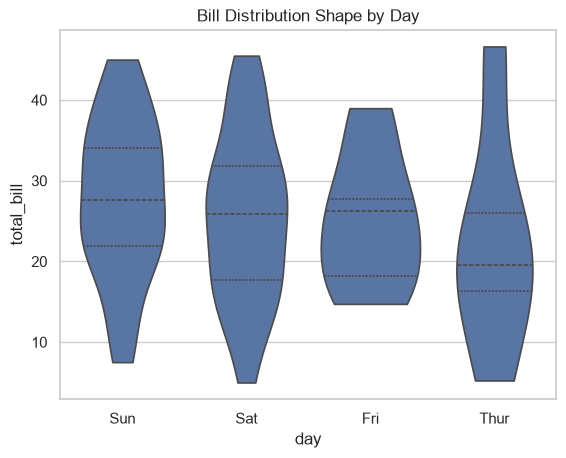

In [12]:
## Violin Plot
sns.violinplot(x='day',y='total_bill',data=tips, inner='quartile', cut=0)
plt.title('Bill Distribution Shape by Day')
plt.show()


`cut=0` keeps the violin within the observed data range. A violin can be misleading for very small groups, so always inspect group counts.


In [13]:
print(tips.groupby('day', observed=True).size().rename('row_count'))


day
Fri      9
Sat     40
Sun     34
Thur    13
Name: row_count, dtype: int64


## 6. Histogram and KDE

A histogram shows counts in bins. KDE draws a smooth estimate of distribution density. KDE can imply values between observations, so use care with tiny samples or discrete variables.


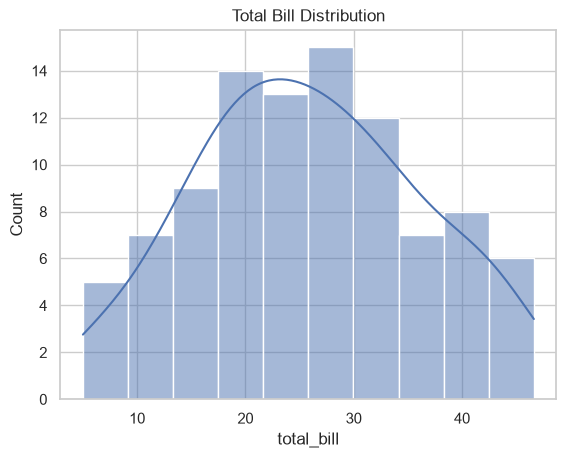

In [14]:
### Histograms
sns.histplot(tips['total_bill'],bins=10,kde=True)
plt.title('Total Bill Distribution')
plt.show()


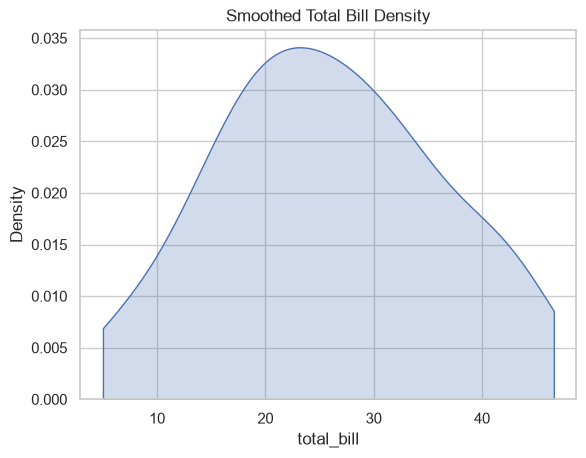

In [15]:
## KDE Plot
sns.kdeplot(tips['total_bill'],fill=True, cut=0)
plt.title('Smoothed Total Bill Density')
plt.show()


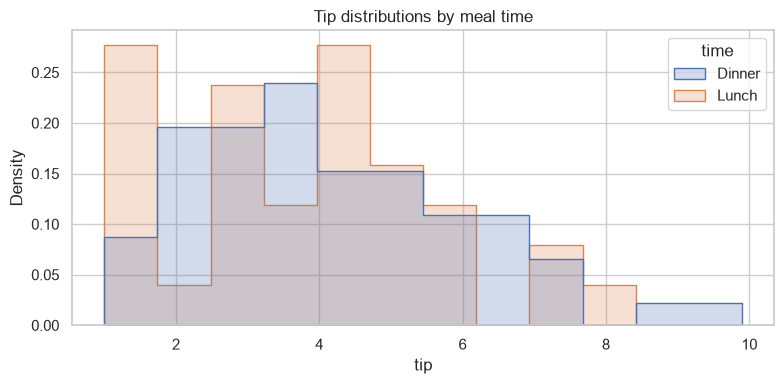

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=tips,
    x='tip',
    hue='time',
    bins=12,
    element='step',
    stat='density',
    common_norm=False,
    ax=ax
)
ax.set_title('Tip distributions by meal time')
fig.tight_layout()
plt.show()


## 7. Count plot

A count plot answers “how many rows belong to each category?” It does not summarize a numeric y-column.


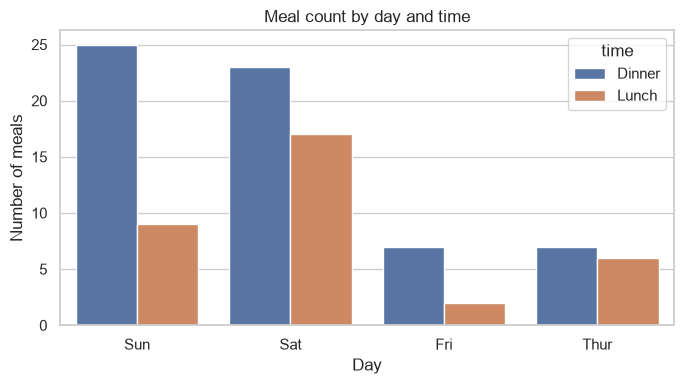

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=tips, x='day', hue='time', ax=ax)
ax.set(title='Meal count by day and time', xlabel='Day', ylabel='Number of meals')
fig.tight_layout()
plt.show()


## 8. Pair plot

A pair plot creates scatter plots for every numeric pair and distributions on the diagonal. It is useful for early exploration but becomes crowded with many columns.


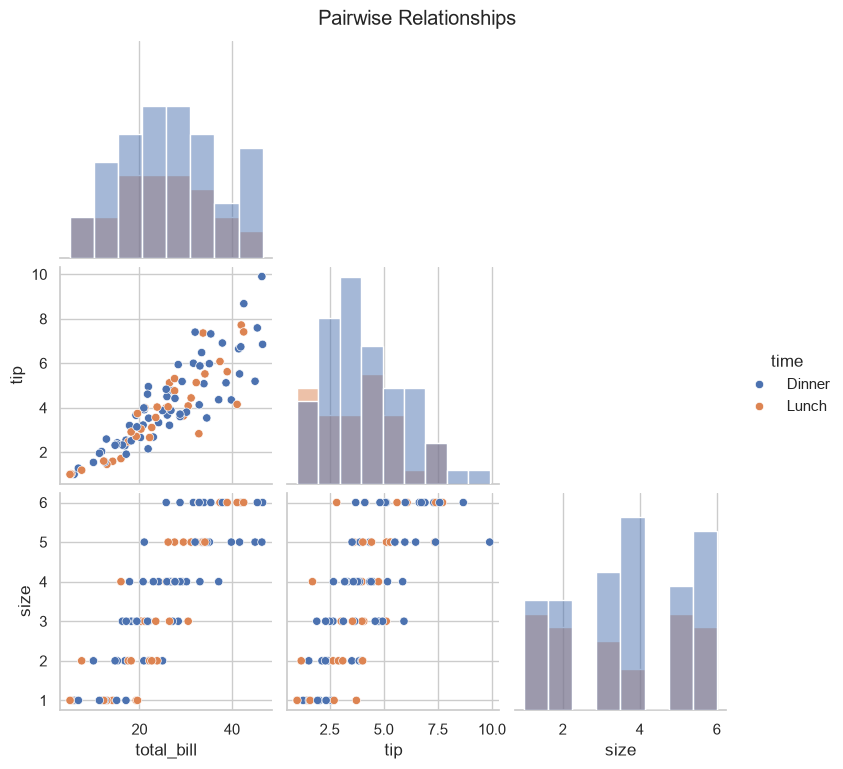

In [18]:
# Pairplot
pair_grid = sns.pairplot(
    tips[['total_bill', 'tip', 'size', 'time']],
    hue='time',
    corner=True,
    diag_kind='hist'
)
pair_grid.fig.suptitle('Pairwise Relationships', y=1.02)
plt.show()


## 9. Correlation heatmap

Correlation measures linear association from −1 to 1. It does not prove causation, and it can miss nonlinear relationships.


In [19]:
## Heatmap
corr=tips[['total_bill','tip','size']].corr()
print(corr)


            total_bill       tip      size
total_bill    1.000000  0.871090  0.858843
tip           0.871090  1.000000  0.753318
size          0.858843  0.753318  1.000000


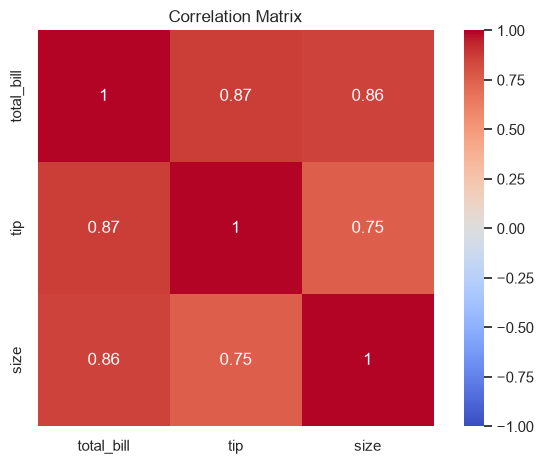

In [20]:
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1,center=0,square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 10. Regression view

`regplot` adds a fitted linear trend. It is an exploratory summary, not proof that the model assumptions or causal story are correct.


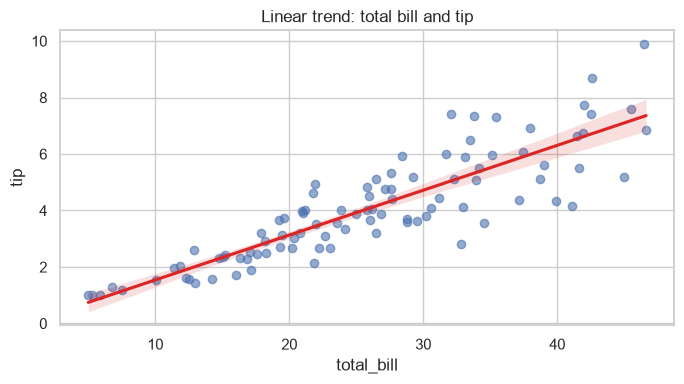

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(
    data=tips,
    x='total_bill',
    y='tip',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': '#DC2626'},
    ax=ax
)
ax.set_title('Linear trend: total bill and tip')
fig.tight_layout()
plt.show()


## 11. Faceting: small multiples

Facets split the same chart into panels with shared rules. This is often clearer than placing every group into one busy chart.


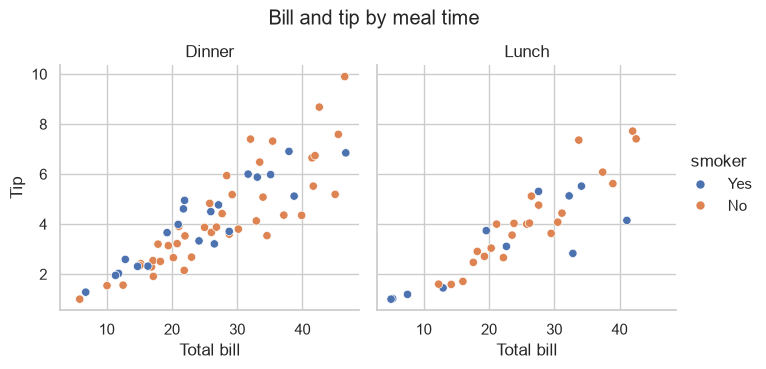

In [22]:
facet = sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    col='time',
    hue='smoker',
    kind='scatter',
    height=3.5,
    aspect=1
)
facet.set_axis_labels('Total bill', 'Tip')
facet.set_titles('{col_name}')
facet.figure.suptitle('Bill and tip by meal time', y=1.05)
plt.show()


## 12. Plot the local sales data


In [23]:
sales_df=pd.read_csv(data_path('sales_data.csv'), parse_dates=['Date'])
sales_df.head()


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


The original bar plots use `estimator=sum`. In modern Seaborn, the explicit string `estimator='sum'` plus `errorbar=None` clearly states that each bar is a total.


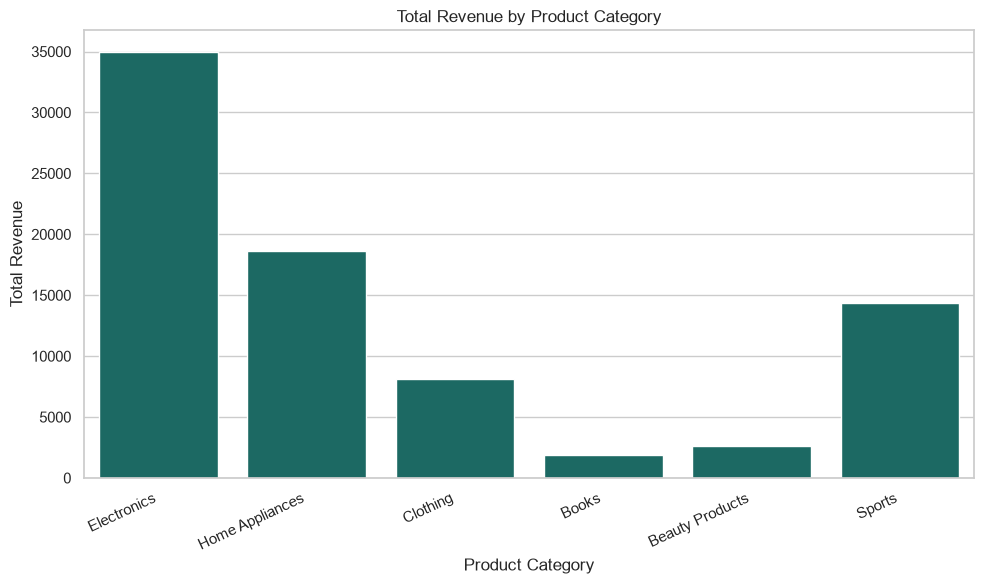

In [24]:
## Plot total sales by product
plt.figure(figsize=(10,6))
sns.barplot(
    x='Product Category',
    y="Total Revenue",
    data=sales_df,
    estimator='sum',
    errorbar=None,
    color='#0F766E'
)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


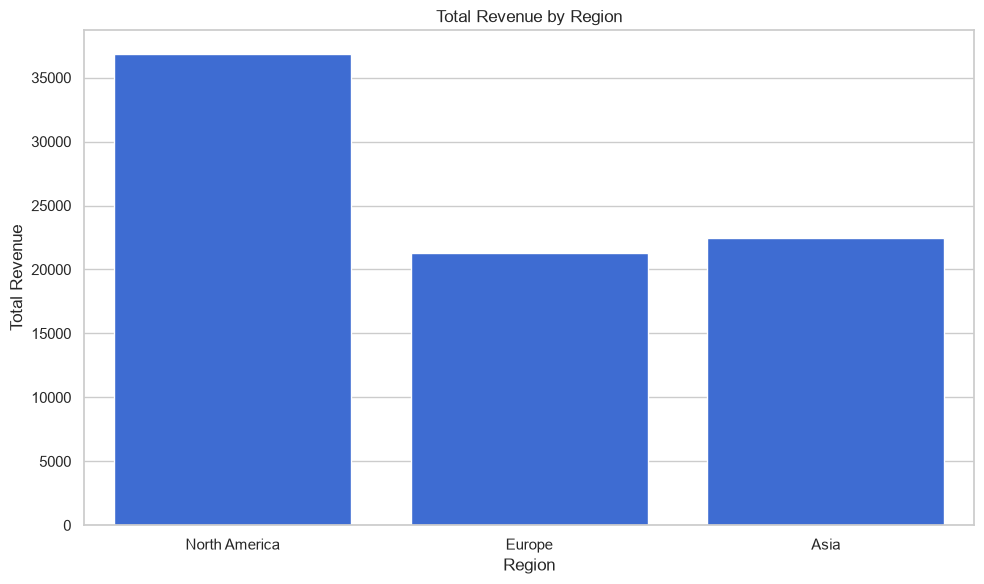

In [25]:
## Plot total sales by Region
plt.figure(figsize=(10,6))
sns.barplot(
    x='Region',
    y="Total Revenue",
    data=sales_df,
    estimator='sum',
    errorbar=None,
    color='#2563EB'
)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()


## 13. Style without hiding the data

Use a restrained theme and purposeful palette. Set style once near the top, then customize only when meaning requires it.


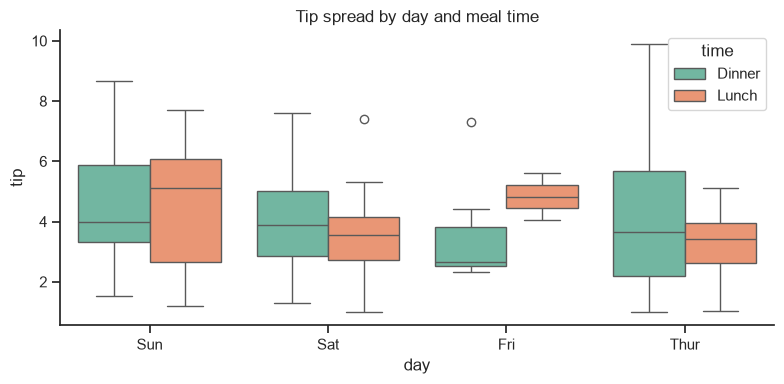

In [26]:
with sns.axes_style('ticks'):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=tips, x='day', y='tip', hue='time', palette='Set2', ax=ax)
    sns.despine(ax=ax)
    ax.set_title('Tip spread by day and meal time')
    fig.tight_layout()
    plt.show()


## 14. Common mistakes

- assuming `barplot` shows totals when its default is a mean;
- treating an uncertainty band as the range of all observations;
- downloading teaching data every run;
- using KDE for tiny or discrete samples without caution;
- mapping too many variables to color, shape, and size;
- interpreting correlation or a regression line as causation;
- creating a giant pair plot with every column;
- forgetting to inspect group sizes behind box or violin plots;
- using a palette without a `hue` meaning.


## Easy revision cheat sheet

| Question | Seaborn function |
|---|---|
| Two numeric variables | `sns.scatterplot` |
| Ordered trend/estimate | `sns.lineplot` |
| Numeric summary by category | `sns.barplot` |
| Category counts | `sns.countplot` |
| Quartiles and outliers | `sns.boxplot` |
| Distribution shape by group | `sns.violinplot` |
| Distribution bins | `sns.histplot` |
| Smoothed density | `sns.kdeplot` |
| Many numeric relationships | `sns.pairplot` |
| Matrix values | `sns.heatmap` |
| Linear trend | `sns.regplot` |
| Panels by category | `sns.relplot(..., col=...)` |

**Core pattern:** `sns.function(data=df, x='column', y='column', hue='group', ax=ax)`.

**Memory trick:** Matplotlib controls the canvas; Seaborn understands tidy columns and can map their meaning to color, shape, size, panels, and statistical summaries.
